# Diabetes Classification with AutoGluon

This project demonstrates the use of **AutoGluon** for predictive modeling on the **UCI Diabetes dataset**. The project will cover:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training with AutoGluon
- Model Evaluation
- Error Analysis
- Advanced Interpretation (e.g., SHAP)


## 🔍 Load and Explore the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import autogluon
from autogluon.tabular import TabularPredictor

# Load dataset (adjust the path as needed)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 📊 Exploratory Data Analysis (EDA)

In [2]:
# Summary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

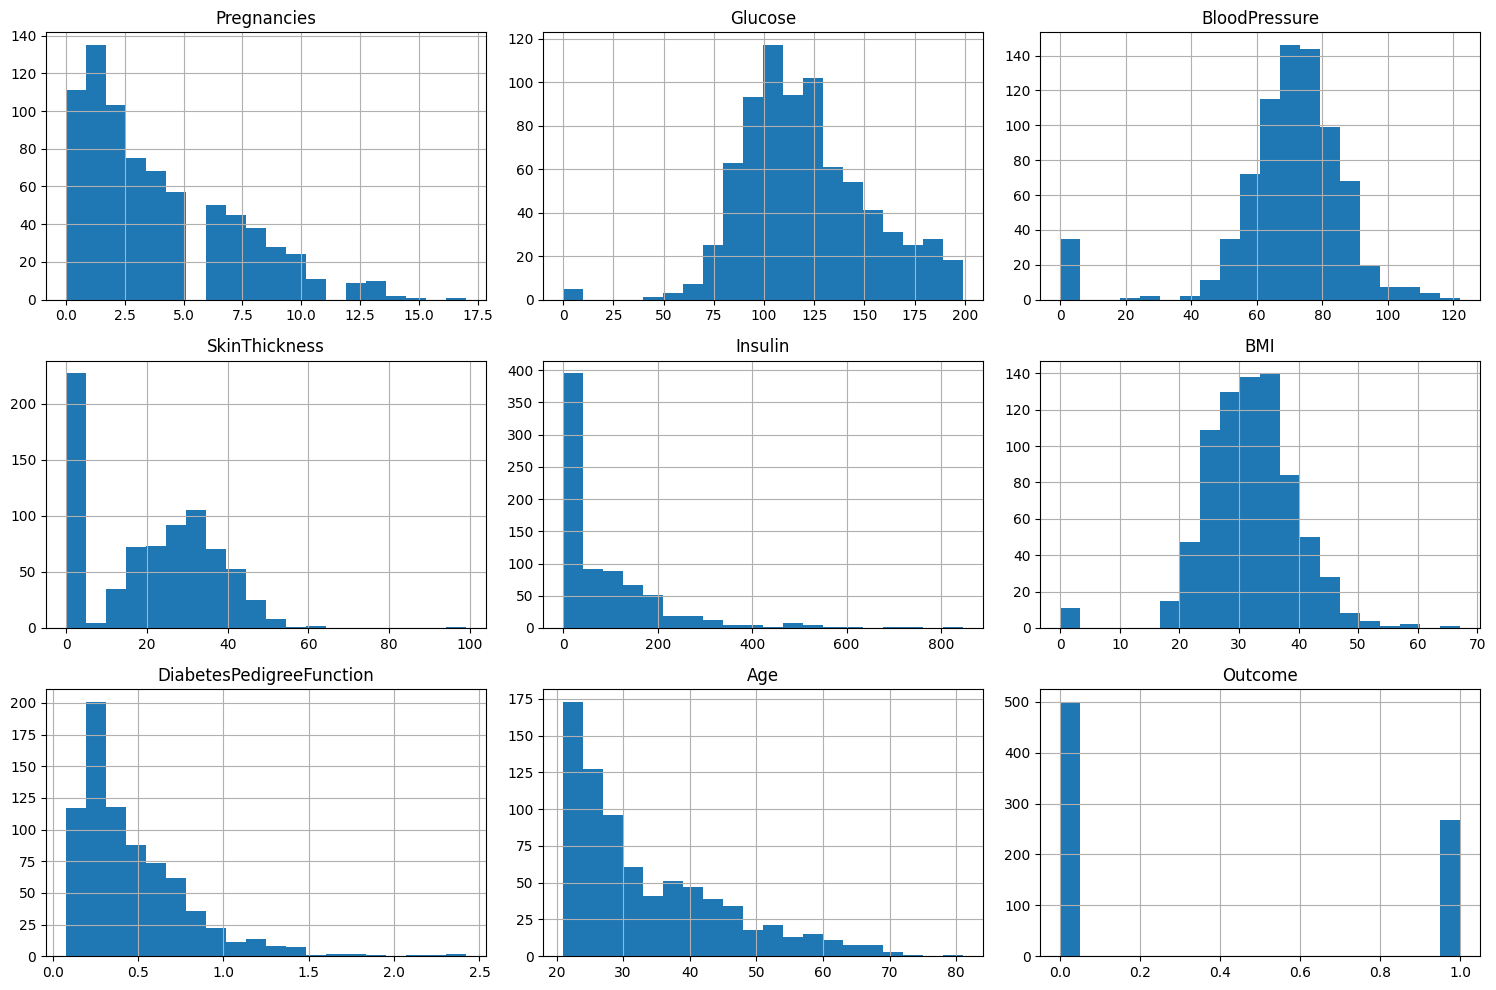

In [4]:
# Distribution plots
df.hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

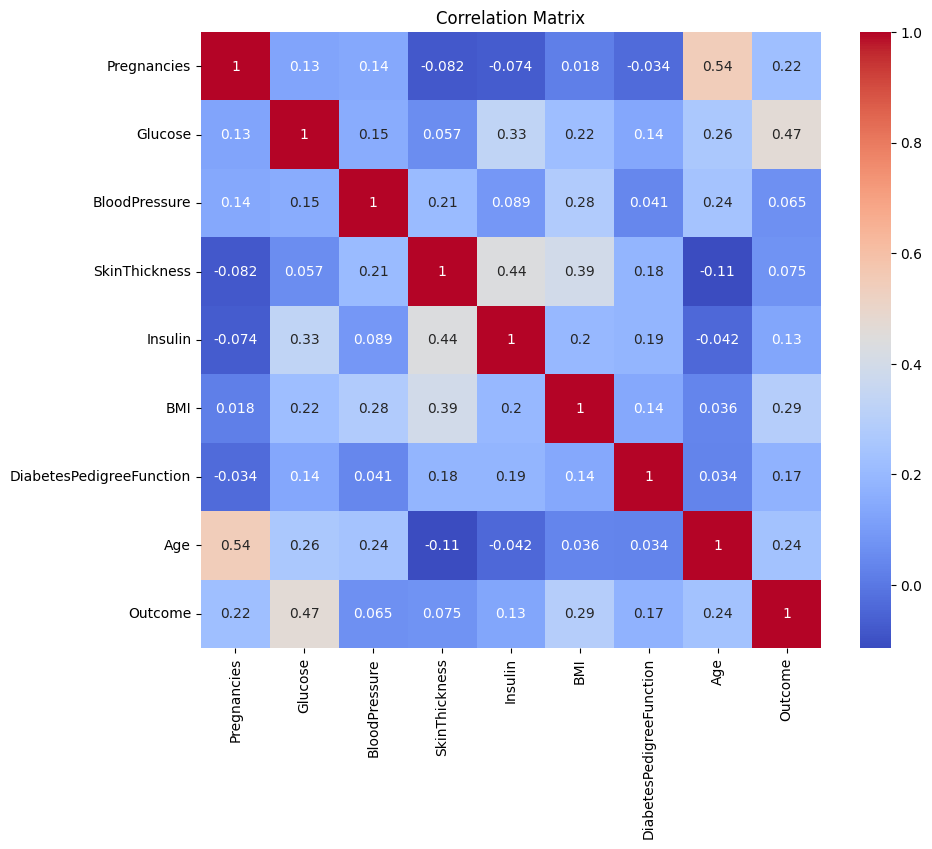

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## ⚖️ Class Balance

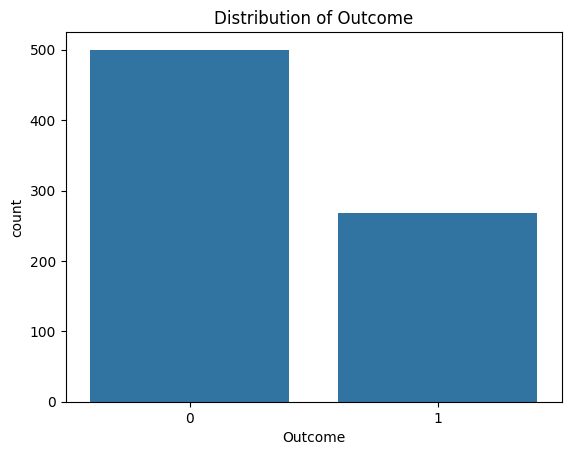

In [6]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome')
plt.show()

## 🚀 Train AutoGluon Classifier

In [7]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
label = 'Outcome'
predictor = TabularPredictor(label=label, eval_metric='accuracy').fit(train_data)

No path specified. Models will be saved in: "AutogluonModels\ag-20250413_143637"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Memory Avail:       0.95 GB / 7.82 GB (12.1%)
Disk Space Avail:   76.99 GB / 237.45 GB (32.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and benchmarks.
	presets='high'         : 

In [8]:
# Show leaderboard
predictor.leaderboard(test_data, silent=True)

C:\Users\5500\anaconda3\envs\Gluon\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT,0.785714,0.780488,accuracy,0.028306,0.007990,0.968016,0.028306,0.007990,0.968016,1,True,3
1,ExtraTreesGini,0.779221,0.747967,accuracy,0.141680,0.078537,1.135375,0.141680,0.078537,1.135375,1,True,8
2,ExtraTreesEntr,0.772727,0.731707,accuracy,0.132878,0.074066,1.246742,0.132878,0.074066,1.246742,1,True,9
3,CatBoost,0.753247,0.788618,accuracy,0.019899,0.003200,1.772112,0.019899,0.003200,1.772112,1,True,7
4,LightGBM,0.746753,0.780488,accuracy,0.025469,0.004154,0.571780,0.025469,0.004154,0.571780,1,True,4
5,XGBoost,0.746753,0.780488,accuracy,0.066458,0.005566,0.623851,0.066458,0.005566,0.623851,1,True,11
6,RandomForestGini,0.746753,0.739837,accuracy,0.118712,0.101152,1.501186,0.118712,0.101152,1.501186,1,True,5
7,NeuralNetTorch,0.740260,0.780488,accuracy,0.042257,0.010756,8.068594,0.042257,0.010756,8.068594,1,True,12
8,NeuralNetFastAI,0.740260,0.780488,accuracy,0.096305,0.027162,2.083495,0.096305,0.027162,2.083495,1,True,10
9,RandomForestEntr,0.733766,0.747967,accuracy,0.078990,0.076545,1.091887,0.078990,0.076545,1.091887,1,True,6


## ✅ Model Evaluation

In [9]:
y_true = test_data[label]
y_pred = predictor.predict(test_data.drop(columns=[label]))
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



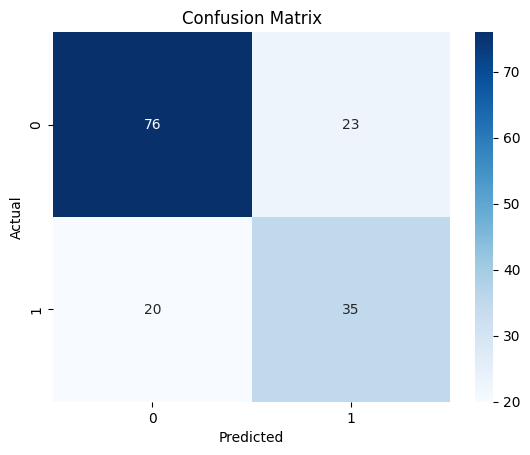

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

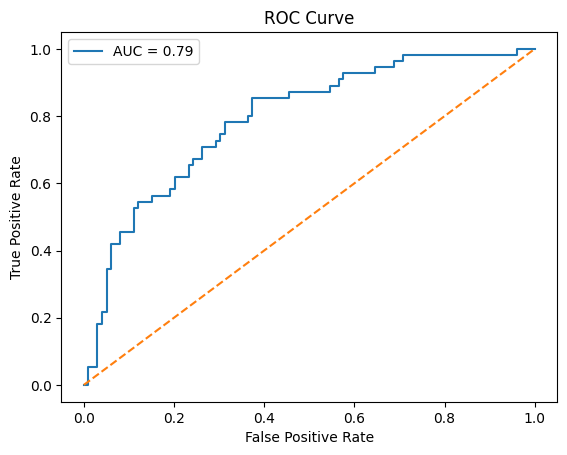

In [11]:
# ROC Curve
y_prob = predictor.predict_proba(test_data.drop(columns=[label]))[1]
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc_score(y_true, y_prob)))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 📌 Feature Importance

Computing feature importance via permutation shuffling for 8 features using 154 rows with 5 shuffle sets...
	1.3s	= Expected runtime (0.26s per shuffle set)
	0.31s	= Actual runtime (Completed 5 of 5 shuffle sets)


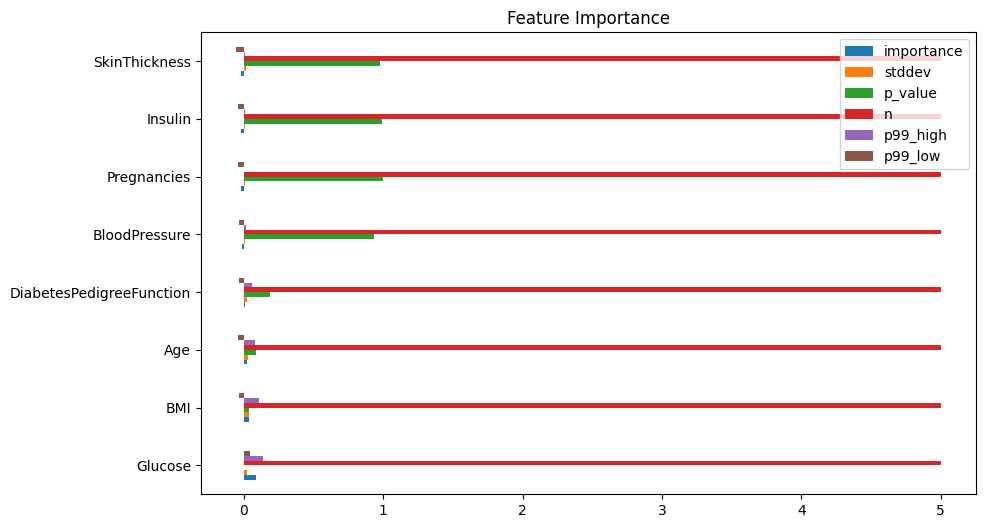

In [12]:
importances = predictor.feature_importance(test_data)
importances.plot(kind='barh', figsize=(10,6))
plt.title('Feature Importance')
plt.show()

## 💾 Save Model

In [13]:
predictor_path = 'diabetes_classification_model'
predictor.save(predictor_path)

## 🧠 Conclusion
The model was trained to predict diabetes diagnosis using patient features. AutoGluon handled feature selection and tuning automatically. The classification results show how well we can predict 'Outcome'.

- AutoGluon automatically trained and selected the best model.
- Key features include Glucose, BMI, Age.
- Evaluation metrics show performance with ROC AUC and confusion matrix.
- Model is saved for reuse.